# Classificação de tumores — Breast Cancer Wisconsin (Diagnostic)

**Disciplina / Curso:** _Pós-graduação — IA para Devs_ · **Tech Challenge — Fase 1**  
**Autores:**
- Eduardo Lucas Maia - rm373880
- Igor Gonçalves Lima - rm373818
- Edvan de Oliveira Sancho - rm371759

**Data:** abril/2026

---

## Resumo

Este trabalho aborda o problema de **classificação binária** de tumores mamários como **benignos** ou **malignos**, utilizando o conjunto público **Wisconsin Breast Cancer (Diagnostic)** carregado a partir do arquivo **`breast_cancer_wisconsin.csv`** (mesmo conjunto da trilha da disciplina). O objetivo principal, no contexto de **triagem médica**, é maximizar o **recall** da classe maligna, reduzindo **falsos negativos** (casos graves classificados erroneamente como benignos). São comparados quatro paradigmas de aprendizado supervisionado — **Regressão Logística**, **k-NN**, **Random Forest** e **SVM** — com validação cruzada e ajuste de hiperparâmetros orientado ao recall.

**Palavras-chave:** classificação; aprendizado de máquina; câncer de mama; validação cruzada; recall.

## 1. Introdução e objetivos

O conjunto Wisconsin contém **30 atributos numéricos** derivados de imagens digitalizadas de aspirados por agulha fina, descrevendo características do núcleo celular (raio, textura, perímetro, área, suavidade, compactação, concavidade, etc.). A variável alvo é binária.

**Por que não basta a acurácia?** Em triagem, um **falso negativo** (tumor **maligno** classificado como benigno) pode atrasar tratamento; já um falso positivo costuma ser resolvido com exames complementares. Por isso priorizamos o **recall da classe maligna**: queremos capturar o máximo de casos graves, aceitando eventualmente mais alarmes falsos que serão confirmados clinicamente.

**Objetivos:**
- Explorar distribuições, correlações e balanceamento das classes.
- Dividir os dados em treino e teste de forma **estratificada**.
- Comparar modelos com **validação cruzada** e **Grid Search** usando **recall** como métrica principal de seleção.
- Avaliar o melhor modelo no conjunto de teste com matriz de confusão, relatório de classificação e curva ROC.

**Roteiro deste notebook:** (1) carga dos dados → (2) EDA → (3) divisão treino/teste → (4) validação cruzada e *tuning* por recall → (5) avaliação honesta no conjunto de teste → (6) interpretação (*Random Forest*) → (7) discussão de limitações e conclusões.

> **Aviso:** Este notebook é **exclusivamente educacional** e **não** substitui diagnóstico médico.

## 2. Bibliotecas

In [18]:
from __future__ import annotations  # habilita anotações de tipo modernas no Python

import json  # manipula dados em formato JSON
import warnings  # controla e filtra mensagens de aviso do Python
from pathlib import Path  # manipula caminhos de arquivos e diretórios de forma orientada a objetos

import matplotlib.pyplot as plt  # cria gráficos e visualizações estáticas
import numpy as np  # realiza operações matemáticas e matriciais de alta performance
import pandas as pd  # manipula e analisa dados em formato tabular (DataFrames)
import seaborn as sns  # cria visualizações estatísticas com interface de alto nível
from sklearn.ensemble import RandomForestClassifier  # implementa o classificador de floresta aleatória
from sklearn.linear_model import LogisticRegression  # implementa o modelo de regressão logística
from sklearn.metrics import (  # fornece métricas para avaliação de modelos de classificação
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    make_scorer,
    recall_score,
)
from sklearn.decomposition import PCA  # realiza redução de dimensionalidade via análise de componentes principais
from sklearn.model_selection import (  # fornece ferramentas para seleção e validação de modelos
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier  # implementa o classificador de k-vizinhos mais próximos
from sklearn.pipeline import Pipeline  # encadeia etapas de pré-processamento e modelagem em sequência
from sklearn.preprocessing import StandardScaler  # padroniza features removendo a média e escalando à variância unitária
from sklearn.svm import SVC  # implementa o classificador de máquina de vetores de suporte

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

## 3. Carga dos dados

O CSV fica em **`tech-challenge-fase1/data/breast_cancer_wisconsin.csv`** (projeto da Fase 1, pasta **irmã** deste notebook na estrutura atual). Idealmente rode o Jupyter com diretório de trabalho na pasta **`Fase 1 - Tech challenge`** (onde estão este `.ipynb` e a pasta `tech-challenge-fase1/`).

Arquivo gerado a partir do Wisconsin Diagnostic. Coluna alvo **`diagnosis`**: `benign` / `malignant`. Codificamos **0 = benign** e **1 = malignant** para recall e ROC na classe maligna.

In [19]:
_CSV_NAME = "breast_cancer_wisconsin.csv"
DATA_PATH = Path("tech-challenge-fase1") / "data" / _CSV_NAME
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        "breast_cancer_wisconsin.csv não encontrado. Use como cwd a pasta onde está este "
        ".ipynb ou a pasta tech-challenge-fase1 e confira tech-challenge-fase1/data/. "
        "Se necessário, edite esta célula e defina DATA_PATH manualmente."
    )

df_raw = pd.read_csv(DATA_PATH)
if "diagnosis" not in df_raw.columns:
    raise ValueError("CSV deve conter a coluna 'diagnosis'.")

df_raw["diagnosis"] = df_raw["diagnosis"].map({"benign": 0, "malignant": 1}).rename("target")
y = df_raw["diagnosis"]
if y.isna().any():
    raise ValueError("Valores em 'diagnosis' devem ser apenas 'benign' ou 'malignant'.")

X = df_raw.drop(columns=["diagnosis"])
class_names = np.array(["benign", "malignant"])

print(df_raw.info())

print("Arquivo:", DATA_PATH.resolve())

print("Valores nulos:")
print(df_raw.isnull().sum())

print("\nRegistros duplicados no df:")
print(df_raw.duplicated().sum()) 

print("\nAtributos categóricos:")
print(df_raw.dtypes.value_counts())

print("\nAmostras:", X.shape[0], "| Colunas:", X.shape[1])

print("\nDistribuição (0=benign, 1=malignant):")
print(y.value_counts().sort_index())

X.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Análise exploratória (EDA)

In [20]:
df_eda = X.copy()
df_eda["diagnosis"] = y.map({0: "benign", 1: "malignant"})
print("Valores ausentes:", df_eda.isna().sum().sum())
df_eda.describe().T

Valores ausentes: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**Interpretação — tabela descritiva:** Verificamos escalas bem diferentes entre variáveis (por exemplo área vs textura); isso motiva usar **padronização** dentro dos *pipelines* dos modelos sensíveis à escala (regressão logística, k-NN, SVM). Também confirmamos ausência relevante de valores ausentes neste CSV.

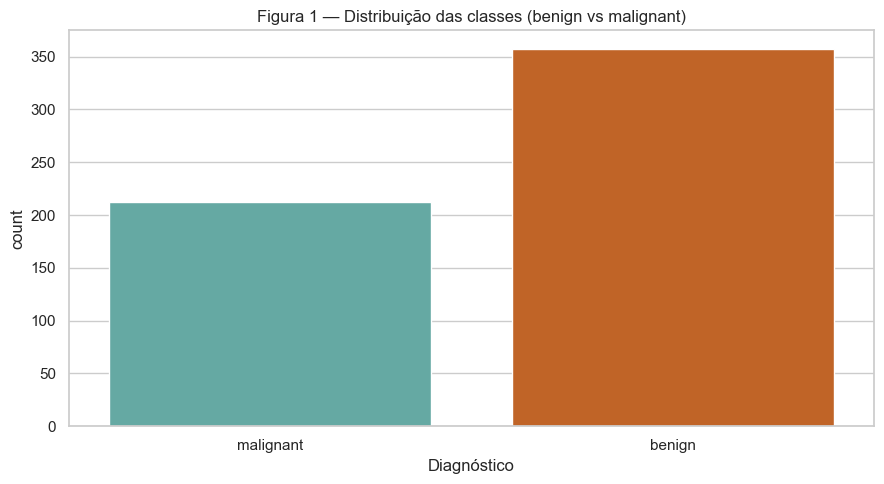

In [21]:
fig, ax = plt.subplots()
sns.countplot(data=df_eda, x="diagnosis", hue="diagnosis", palette=["#5ab4ac", "#d95f0e"], legend=False, ax=ax)
ax.set_title("Figura 1 — Distribuição das classes (benign vs malignant)")
ax.set_xlabel("Diagnóstico")
plt.tight_layout()
plt.show()

**Interpretação (Figura 1):** Observamos se as classes estão desbalanceadas. Um desvio forte exigiria estratégias específicas (`class_weight`, *oversampling*, etc.); aqui esperamos proporções relativamente próximas, compatíveis com usar recall e validação estratificada sem correções agressivas.

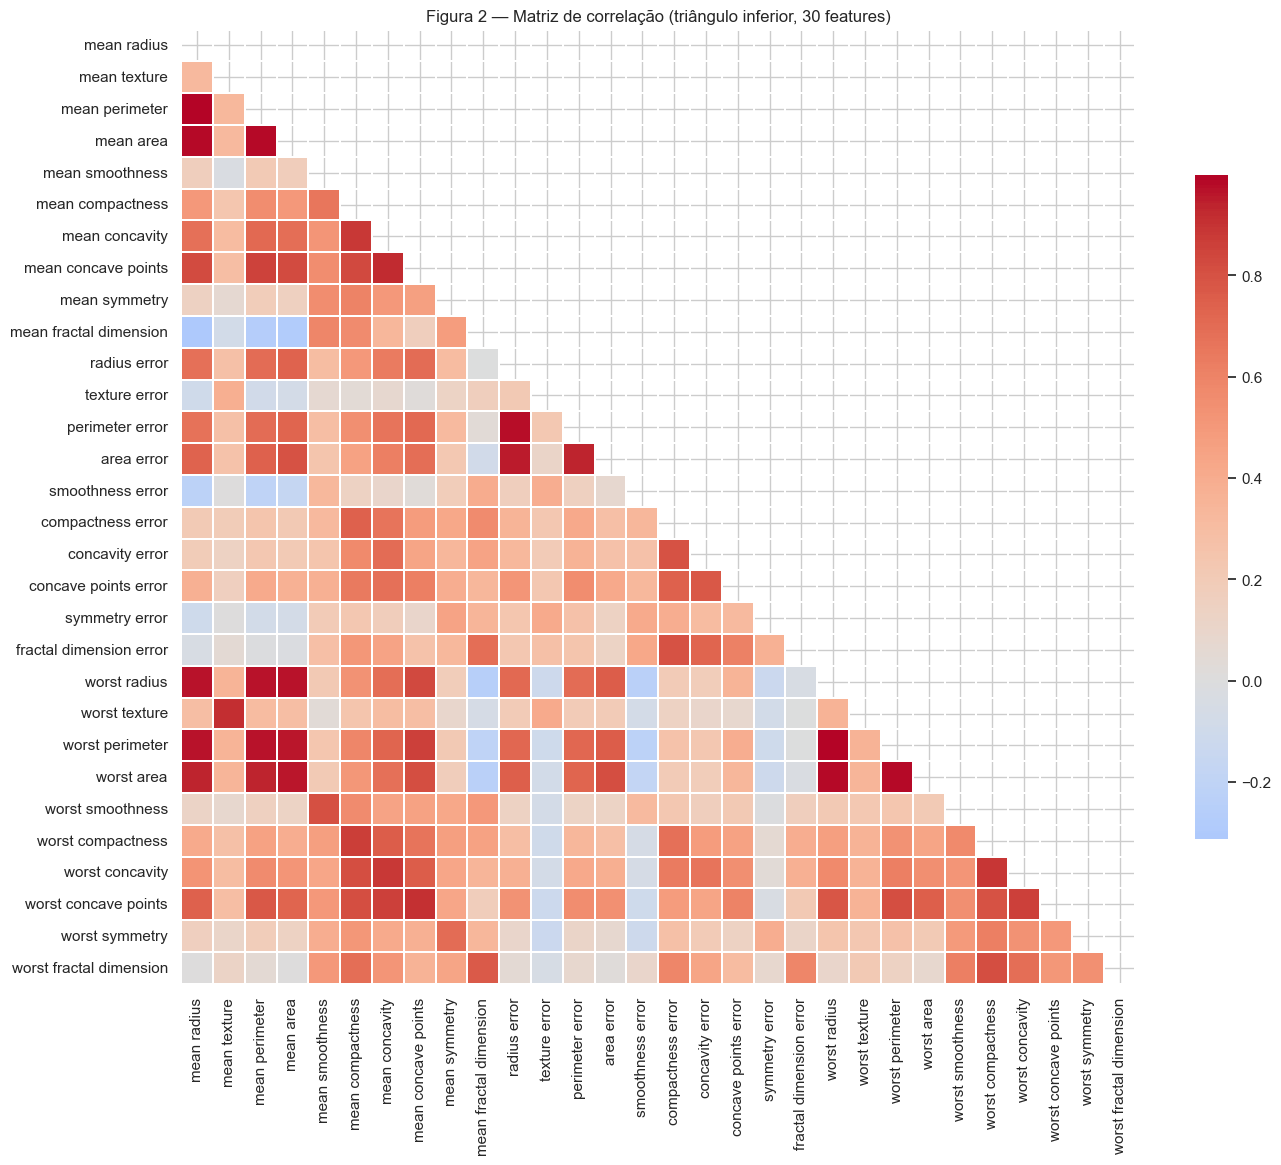

In [22]:
# Figura 2 — correlação entre todas as features (multicolinearidade / redundância)
corr_full = X.corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool))
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_full,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.15,
    cbar_kws={"shrink": 0.65},
)
plt.title("Figura 2 — Matriz de correlação (triângulo inferior, 30 features)")
plt.tight_layout()
plt.show()

**Interpretação (Figura 2):** Muitas features são **fortemente correlacionadas** (ex.: raio, perímetro e área), o que é esperado geometricamente. Modelos lineares podem sofrer com redundância; ensembles de árvores costumam lidar bem com interações e não-linearidades. Esta visão qualifica o que esperamos dos diferentes algoritmos adiante — não substitui o modelo, mas explica comportamentos típicos.

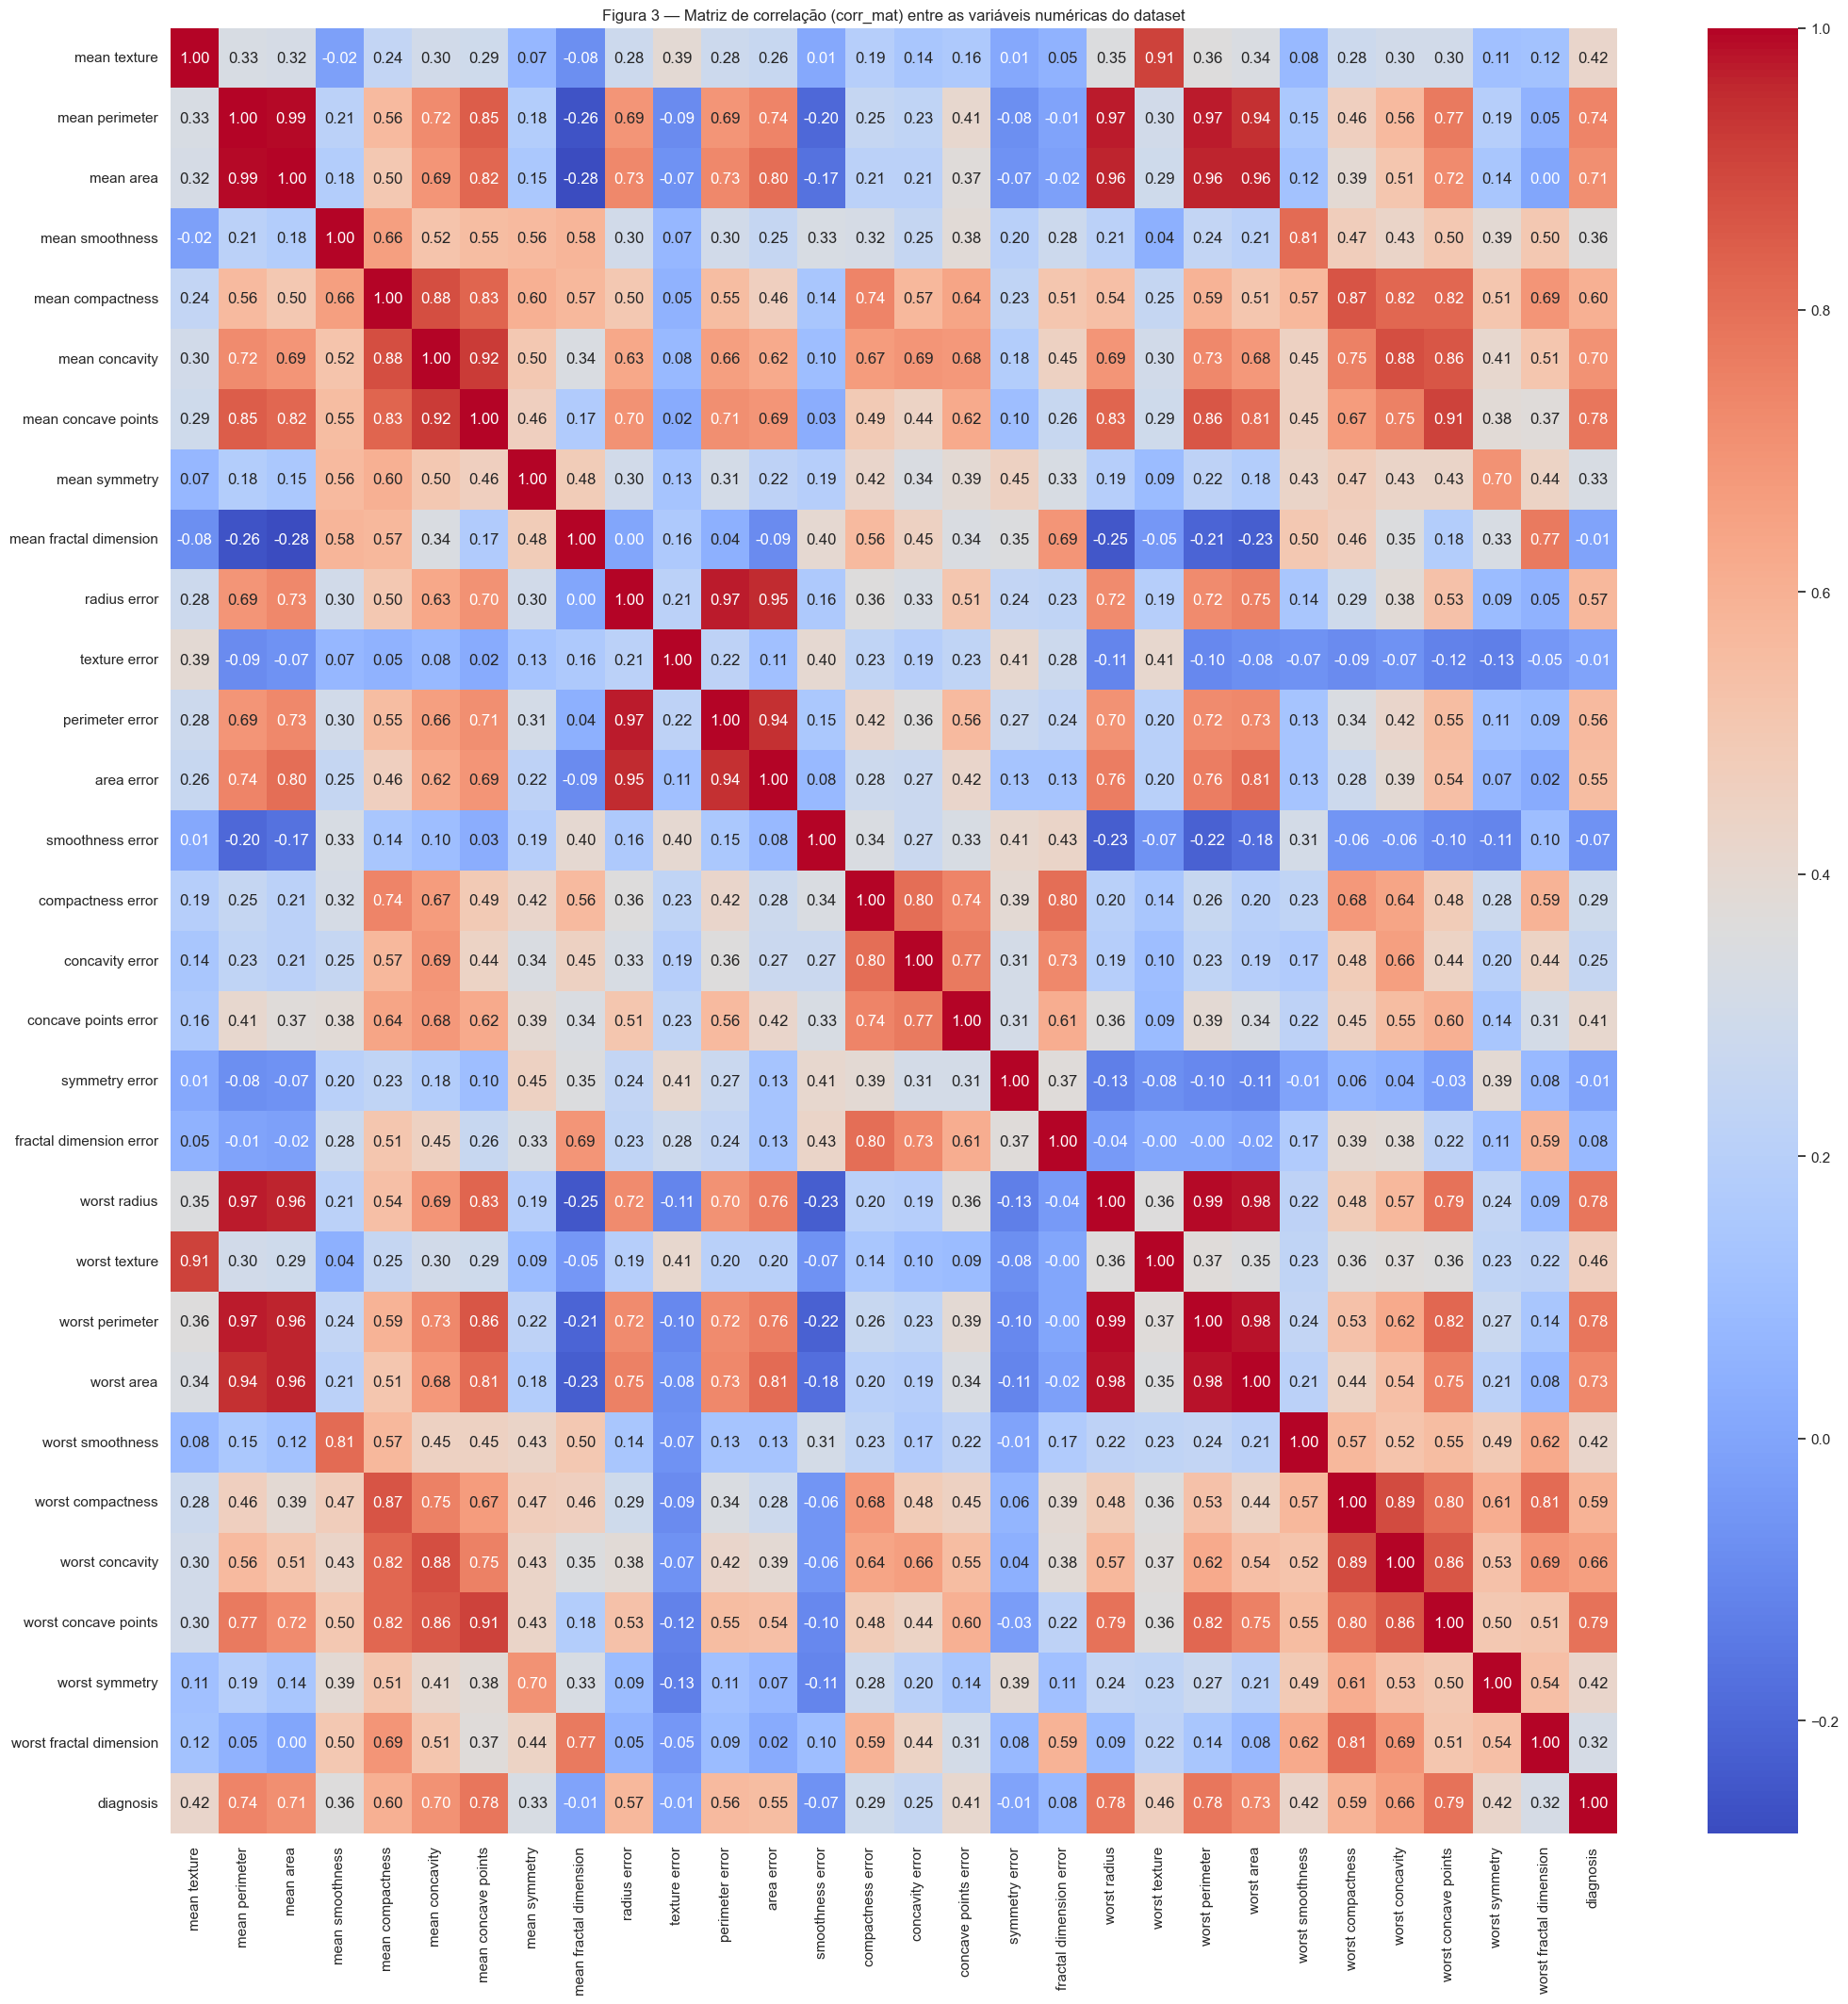

In [23]:
corr_mat = df_raw.iloc[:,1:].corr().round(2)
corr_mat['texture error'].sort_values(ascending = False)*100
fig = plt.figure(figsize =(20,20))
plt.title("Figura 3 — Matriz de correlação (corr_mat) entre as variáveis numéricas do dataset")
plt.tight_layout()
sns.heatmap(data = corr_mat, cmap = 'coolwarm', annot = True, fmt = '.2f')
plt.show()

**Interpretação (Figura 3):** O gráfico monta um heatmap da matriz de correlação (corr_mat) entre as variáveis numéricas do dataset: cada célula quantifica quanto duas features variam linearmente juntas (−1 a 1), com valores impressos (annot) para leitura rápida. O objetivo é visualizar redundâncias e associações entre os atributos na EDA antes da modelagem.

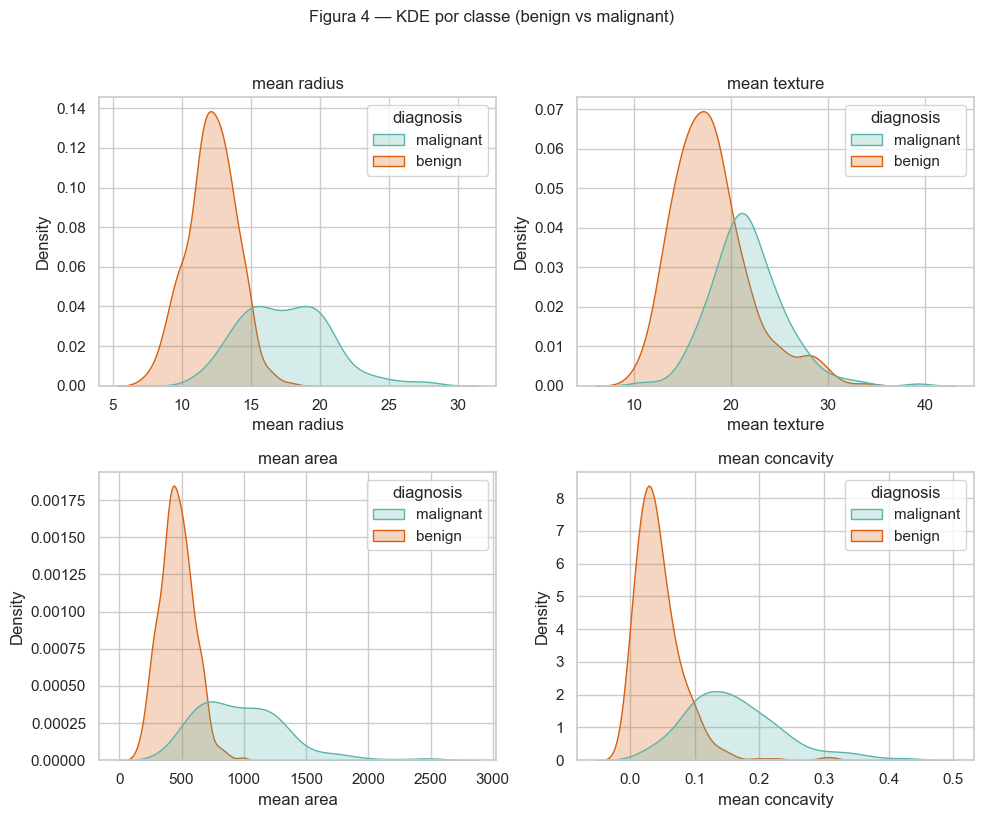

In [24]:
# Figura 4 — densidade (KDE) de algumas variáveis por diagnóstico (separação visual)
features_demo = ["mean radius", "mean texture", "mean area", "mean concavity"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, features_demo):
    sns.kdeplot(data=df_eda, x=col, hue="diagnosis", fill=True, ax=ax, palette=["#5ab4ac", "#d95f0e"])
    ax.set_title(col)
plt.suptitle("Figura 4 — KDE por classe (benign vs malignant)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

**Interpretação (Figura 4):** Quando as curvas por classe se **separam** no eixo horizontal, a variável ajuda a discriminar maligno vs benigno. Sobreposição forte indica regiões mais ambíguas — onde qualquer modelo tenderá a errar mais.

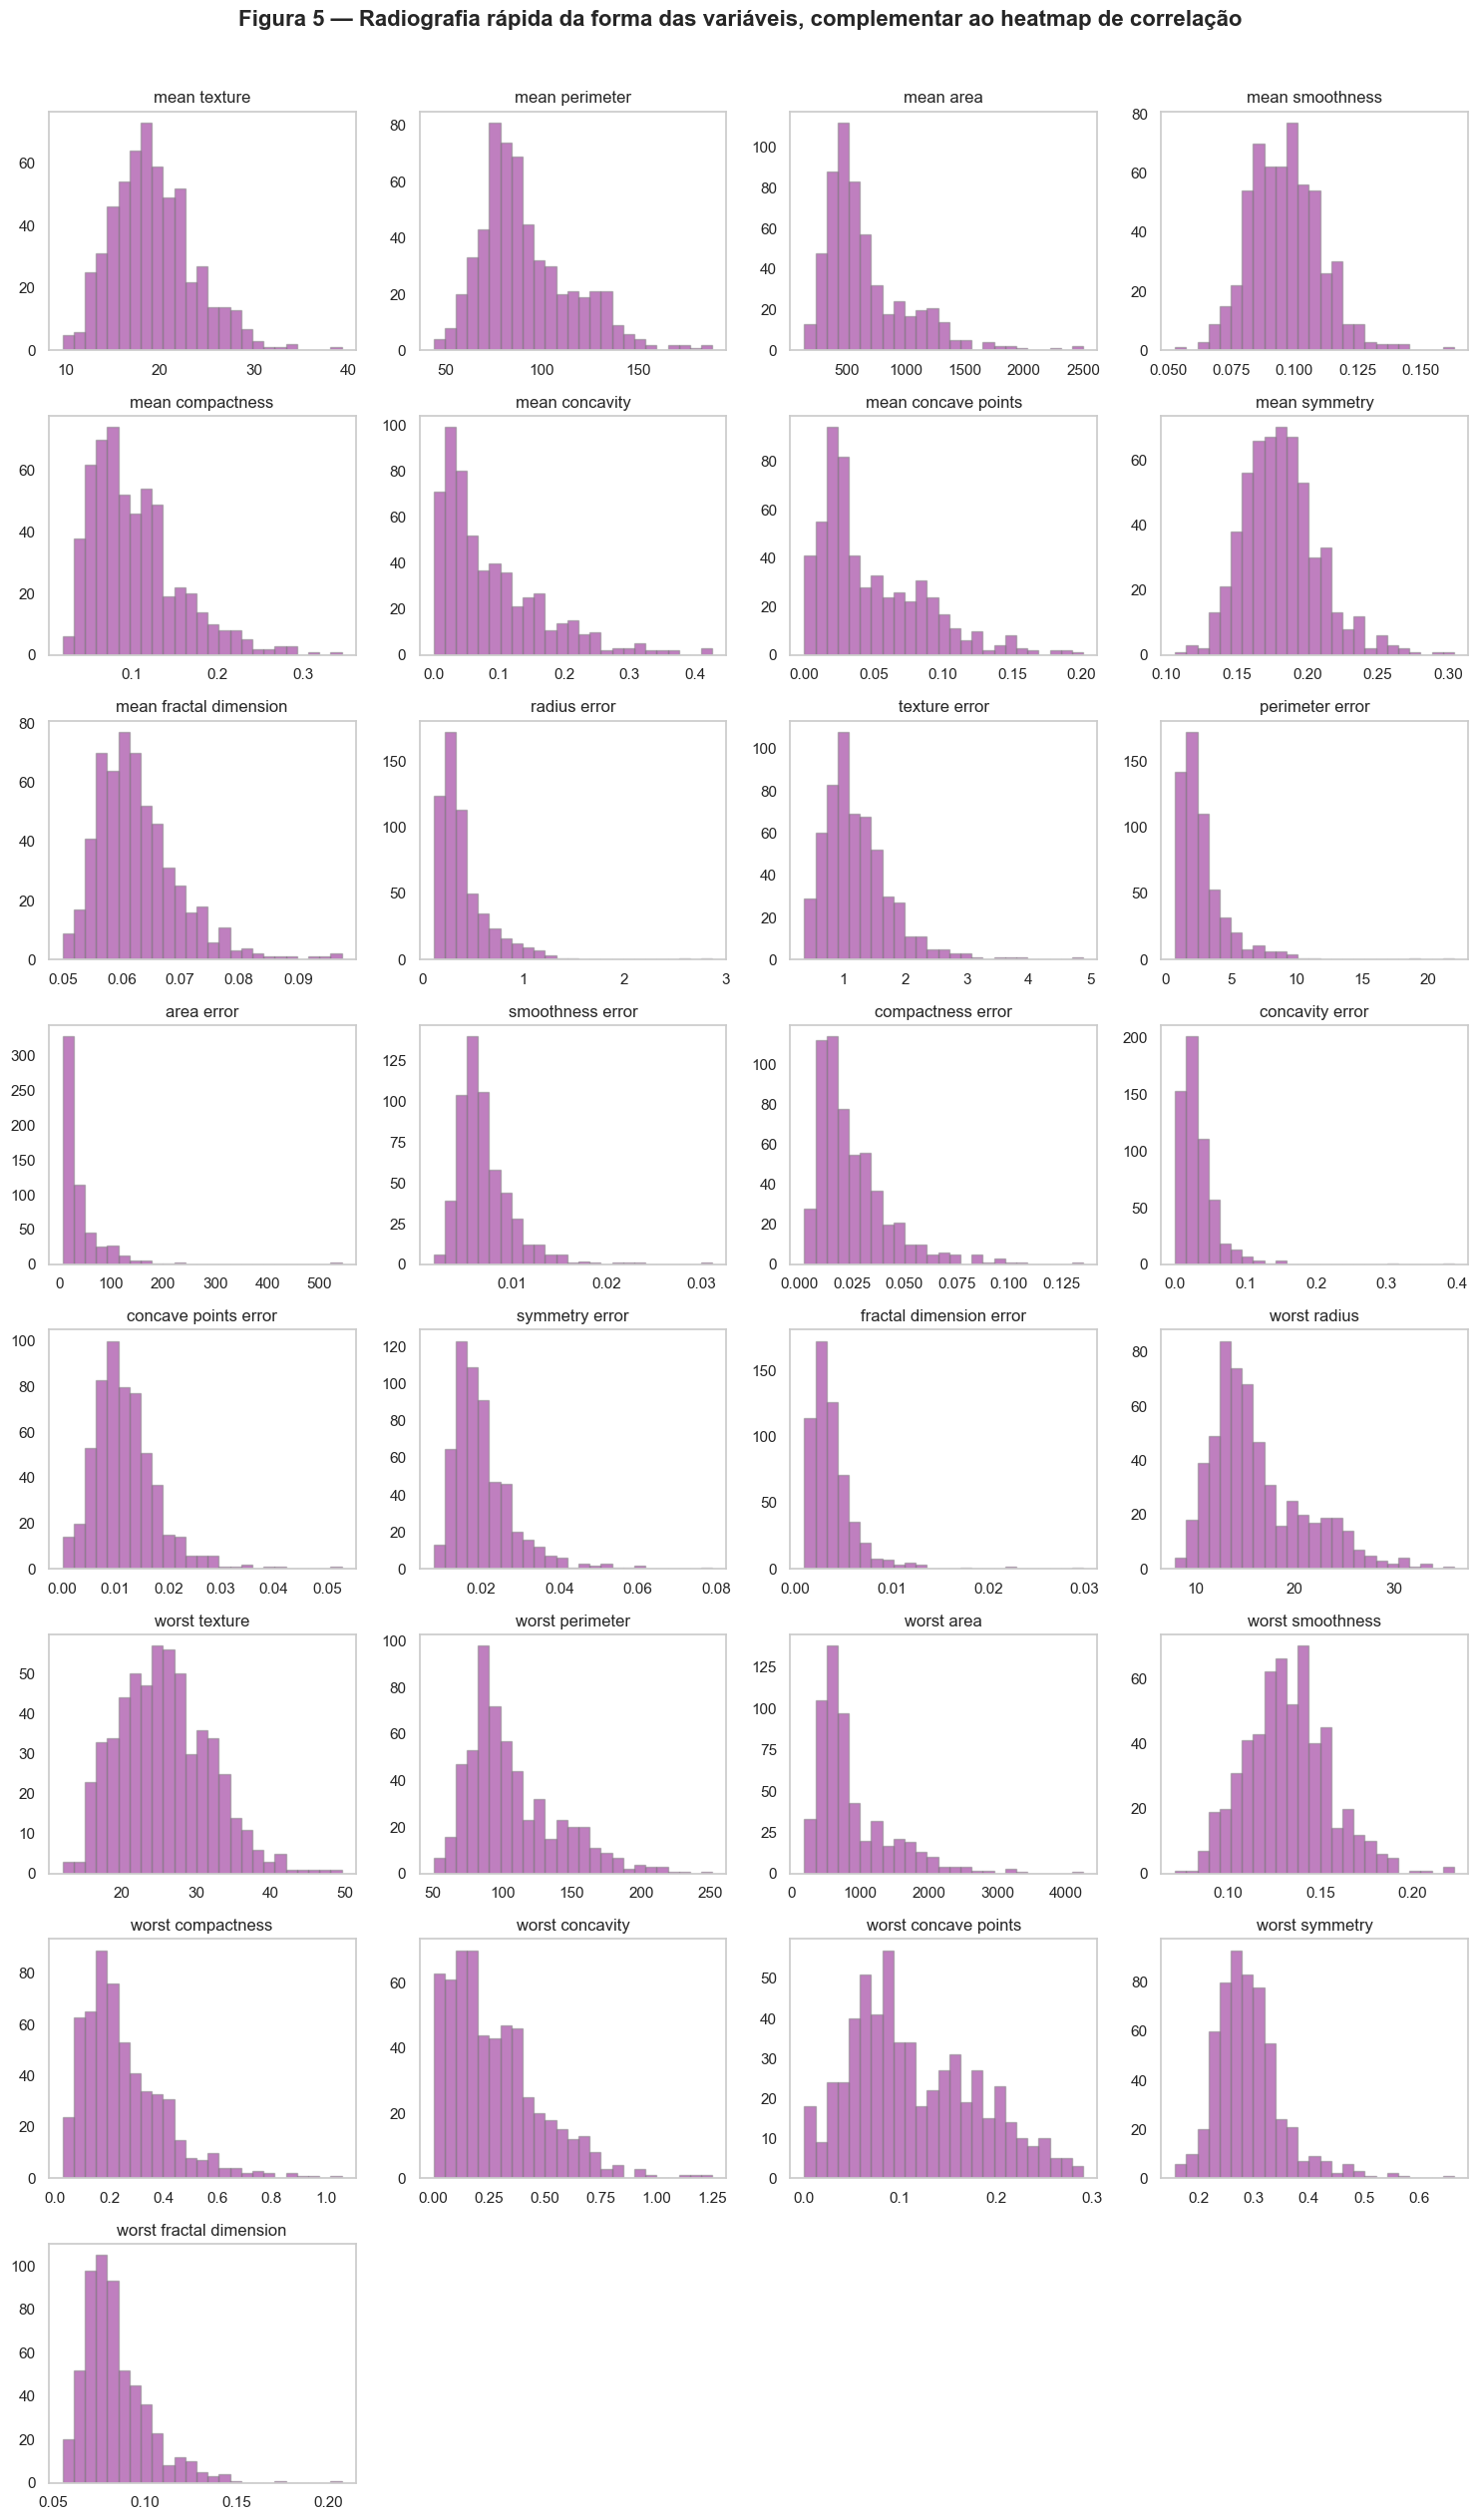

In [25]:
X.iloc[:,1:].hist(bins=25, figsize=(15, 25), layout=(-1, 4), edgecolor="gray", color = 'purple', alpha = 0.5, grid = False)
plt.suptitle('Figura 5 — Radiografia rápida da forma das variáveis, complementar ao heatmap de correlação', y = 1.01, fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

**Interpretação (Figura 5):** Nestes gráficos a finalidade é explorar a forma de cada variável numérica (histogramas com vários bins), ver se as distribuições são simétricas ou assimétricas, se há caudas longas/outliers e em que escala cada feature varia, tudo isso orienta escalonamento, escolha de modelo e interpretação dos resultados.

### 4.1 Visualização ilustrativa (PCA)

Projeto dos dados nas **duas primeiras componentes principais**, apenas para **explorar separação visual** entre classes. **Não** substituímos as 30 features por PCA no treino dos classificadores abaixo — os modelos usam as features originais nos *pipelines* descritos na seção 6.

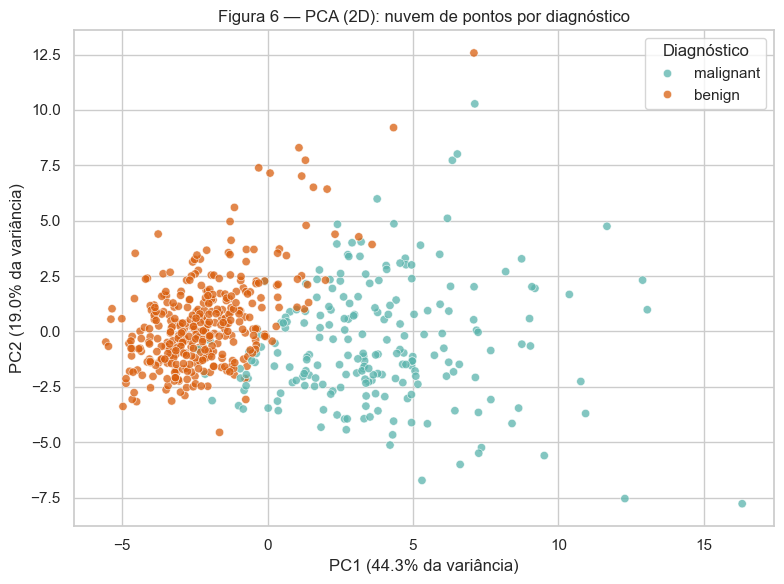

Soma da variância nas 2 PCs: 63.2%


In [26]:
Xp = StandardScaler().fit_transform(X)
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca_viz.fit_transform(Xp)
pca_df = pd.DataFrame({"PC1": Z[:, 0], "PC2": Z[:, 1], "diagnosis": y.map({0: "benign", 1: "malignant"})})
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="diagnosis", palette=["#5ab4ac", "#d95f0e"], alpha=0.75)
evr = pca_viz.explained_variance_ratio_
plt.title("Figura 6 — PCA (2D): nuvem de pontos por diagnóstico")
plt.xlabel(f"PC1 ({evr[0]*100:.1f}% da variância)")
plt.ylabel(f"PC2 ({evr[1]*100:.1f}% da variância)")
plt.legend(title="Diagnóstico")
plt.tight_layout()
plt.show()
print(f"Soma da variância nas 2 PCs: {(evr[0]+evr[1])*100:.1f}%")

**Interpretação (Figura 6):** Se benignos e malignos formam **nuvens parcialmente separáveis**, esperamos fronteiras de decisão utilizáveis; grande sobreposição indicaria problema mais difícil. As porcentagens em cada eixo mostram quanta variabilidade captamos em só duas dimensões — típico ser **bem menos de 100%**, o que reforça por que não reduzimos dimensionalidade para treinar os modelos principais neste relatório.

## 5. Divisão treino / teste

Hold-out **80/20**, **estratificado** pelo alvo e `random_state=RANDOM_STATE` para reprodutibilidade.

**Por que estratificar?** Garantimos que treino e teste tenham proporções parecidas de benignos/malignos; caso contrário, métricas no conjunto de teste poderiam oscilar só por sorteio de amostras.

**Papel do conjunto de teste:** Fica **reservado** até o final — não entra no *GridSearch* — para simular **generalização** a dados novos (avaliação mais honesta que repetir no treino).

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (455, 30) | Teste: (114, 30)


### Justificativa da métrica de seleção (*tuning*)

No `GridSearchCV` usamos **`recall`** (classe positiva = malignant) como métrica para escolher hiperparâmetros: isso incorpora o **custo assimétrico** discutido na introdução — errar omitindo um caso grave costuma ser mais grave do que alarme falso que exames posteriores esclarecem.

O **conjunto de teste** não participa da busca em grade; serve só para uma leitura **única** de desempenho em dados não vistos (ainda assim, uma estimativa; em projeto real pediria-se validação externa ou mais dados).

## 6. Modelos e grade de hiperparâmetros

- **Regressão logística** e **SVM/k-NN** são sensíveis à escala → `StandardScaler` no `Pipeline`.
- **Random Forest** usa partições por limiar; o escalonamento é opcional; aqui mantemos features brutas.
- **Seleção:** `GridSearchCV` com **recall** (classe positiva = malignant).

In [28]:
def build_pipelines_and_grids():
    models = {
        "Regressão logística": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
            ]),
            {
                "model__C": [0.1, 1.0, 10.0],
                "model__class_weight": [None, "balanced"],
            },
        ),
        "k-NN": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier()),
            ]),
            {
                "model__n_neighbors": [5, 9, 15],
                "model__weights": ["uniform", "distance"],
                "model__metric": ["euclidean", "manhattan"],
            },
        ),
        "Random Forest": (
            Pipeline([("model", RandomForestClassifier(random_state=RANDOM_STATE))]),
            {
                "model__n_estimators": [200, 400],
                "model__max_depth": [None, 6, 10],
                "model__min_samples_leaf": [1, 2, 4],
            },
        ),
        "SVM": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", SVC(probability=True, random_state=RANDOM_STATE)),
            ]),
            {"model__C": [0.5, 1.0, 2.0], "model__kernel": ["rbf", "linear"]},
        ),
    }
    return models


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}

In [29]:
models = build_pipelines_and_grids()
rows = []
best_name = None
best_score = -1.0
best_estimator = None

for name, (pipeline, param_grid) in models.items():
    baseline = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=make_scorer(recall_score),
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)

    rows.append(
        {
            "modelo": name,
            "cv_accuracy_mean": baseline["test_accuracy"].mean(),
            "cv_recall_mean": baseline["test_recall"].mean(),
            "cv_f1_mean": baseline["test_f1"].mean(),
            "cv_roc_auc_mean": baseline["test_roc_auc"].mean(),
            "best_recall_grid": grid.best_score_,
            "best_params": json.dumps(grid.best_params_),
        }
    )

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_name = name
        best_estimator = grid.best_estimator_

results_df = pd.DataFrame(rows).sort_values("best_recall_grid", ascending=False)
results_df

,modelo,cv_accuracy_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,best_recall_grid,best_params
0,Regressão logística,0.973626,0.952941,0.964048,0.995769,0.958824,"{""model__C"": 1.0, ""model__class_weight"": ""bala..."
3,SVM,0.971429,0.947059,0.960987,0.994943,0.947059,"{""model__C"": 0.5, ""model__kernel"": ""linear""}"
2,Random Forest,0.964835,0.941176,0.951945,0.988906,0.941176,"{""model__max_depth"": null, ""model__min_samples..."
1,k-NN,0.964835,0.917647,0.951042,0.987100,0.935294,"{""model__metric"": ""manhattan"", ""model__n_neigh..."


**Interpretação — tabela de resultados:** A coluna `cv_*_mean` resume o desempenho **antes** do *tuning* (pipelines com hiperparâmetros padrão). Já `best_recall_grid` é o recall obtido **após** escolher a melhor combinação em cada modelo. Esperamos que o *grid* melhore ou mantenha o recall em relação ao baseline informal da primeira coluna — comparamos visualmente na figura seguinte.

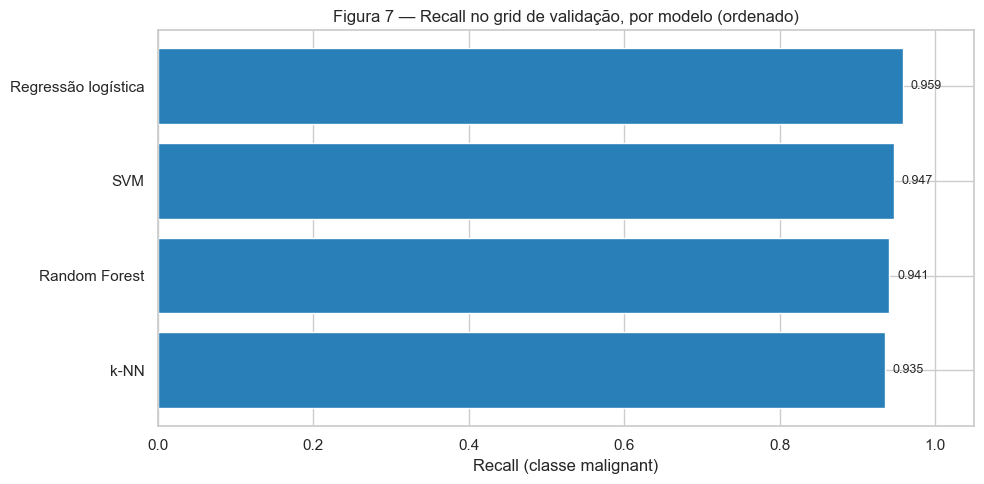

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
r = results_df.sort_values("best_recall_grid", ascending=True)
hb = ax.barh(r["modelo"], r["best_recall_grid"], color="#2980b9", label="Melhor recall (GridSearch)")
ax.set_xlabel("Recall (classe malignant)")
ax.set_xlim(0, 1.05)
ax.set_title("Figura 7 — Recall no grid de validação, por modelo (ordenado)")
for i, v in enumerate(r["best_recall_grid"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretação (Figura 7):** O modelo cuja barra está **mais à direita** (maior recall no grid) foi o preferido pelo `GridSearchCV`. Diferenças pequenas entre modelos são normais neste conjunto relativamente “fácil”; ainda assim, a escolha explícita por recall mantém o alinhamento com o objetivo de triagem.

In [31]:
print(f"Melhor modelo (maior recall no grid): {best_name}")
print(f"Recall (validação, grid): {best_score:.4f}")
print("Hiperparâmetros:", json.loads(results_df.loc[results_df['modelo'] == best_name, 'best_params'].iloc[0]))

Melhor modelo (maior recall no grid): Regressão logística
Recall (validação, grid): 0.9588
Hiperparâmetros: {'model__C': 1.0, 'model__class_weight': 'balanced'}


**Interpretação — escolha do modelo:** Confirmamos qual pipeline foi refinado pelo *grid search* e imprimimos os hiperparâmetros vencedores (`best_params`). Na próxima seção medimos o mesmo estimador no **teste** — esperamos coerência com o recall de validação, mas não necessariamente o mesmo valor (o teste é uma única amostra de ~20% dos dados).

## 7. Avaliação no conjunto de teste

In [32]:
y_pred = best_estimator.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))
print("Recall (malignant):", recall_score(y_test, y_pred))

              precision    recall  f1-score   support

      benign       0.97      0.99      0.98        72
   malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Recall (malignant): 0.9523809523809523


**Interpretação — métricas no teste:** O relatório síntese mostra precisão/recall/F1 por classe. Para o nosso objetivo, olhamos com atenção o **recall da classe malignant**: valores altos indicam poucos falsos negativos. Precision da classe maligna pode ser menor se aceitamos mais alarmes falsos — trade-off esperado quando priorizamos recall.

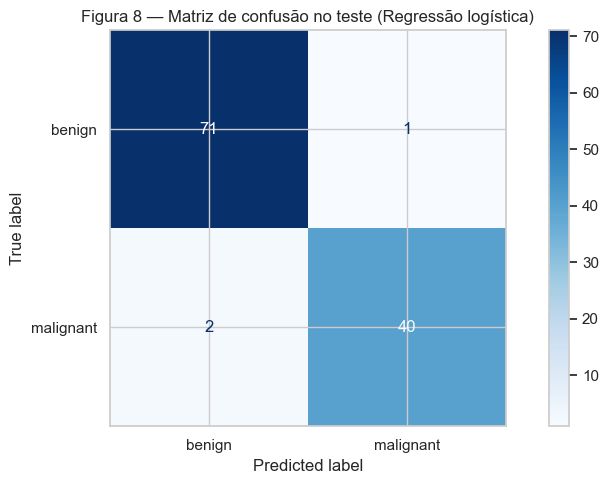

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=class_names,
    cmap="Blues",
    values_format="d",
)
plt.title(f"Figura 8 — Matriz de confusão no teste ({best_name})")
plt.tight_layout()
plt.show()

**Interpretação (Figura 8):** Na diagonal principal estão os acertos; fora dela, erros. Contamos quantos malignos foram chamados de benignos (**falso negativo**, canto que importa para recall) e o simétrico (**falso positivo**).

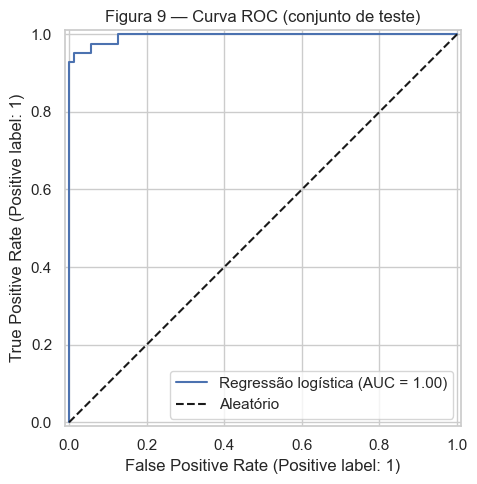

In [34]:
if hasattr(best_estimator, "predict_proba"):
    roc_disp = RocCurveDisplay.from_predictions(y_test, best_estimator.predict_proba(X_test)[:, 1], name=best_name)
    plt.title("Figura 9 — Curva ROC (conjunto de teste)")
    plt.plot([0, 1], [0, 1], "k--", label="Aleatório")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Interpretação (Figura 9):** A ROC resume a capacidade de distinguir classes usando vários limiares de probabilidade. Quanto mais a curva **afasta-se da diagonal** (classificador aleatório), melhor; AUC alto costuma acompanhar bom equilíbrio entre sensibilidade e especificidade.

## 8. Discussão, limitações e conclusões

### Síntese

- O conjunto Wisconsin é **razoavelmente balanceado**; mesmo assim, **recall** e **F1** complementam a acurácia sob uma perspectiva clínica de triagem.
- O `GridSearchCV` orientado ao **recall da classe maligna** explicita o custo assimétrico discutido na introdução (evitar falsos negativos).
- No conjunto de teste, avaliamos **uma vez** o modelo escolhido na validação — boa prática para não **vazar** informação do teste para o *tuning*.

### Limitações deste experimento

- **Dados históricos e contexto específico:** amostra antiga (Wisconsin); perfil populacional e protocolos atuais podem diferir.
- **Pequeno teste (~20%):** métricas pontuais variam se mudarmos a semente ou o split; idealmente repetiríamos avaliações com mais dados ou validação externa.
- **Grid de hiperparâmetros:** escolha pragmática (tempo de execução vs. exaustividade); uma solução diferente no *grid* poderia alterar levemente o ranking.
- **Atributos agregados:** não são imagens brutas; não substituem laudo especializado.

### Mini-glossário

| Termo | Significado breve |
|-------|---------------------|
| Hold-out | Separar parte dos dados só para avaliação final (aqui 20%). |
| Estratificação | Manter proporção de classes ao dividir treino/teste. |
| Recall | Fração de positivos reais que o modelo detectou (sensibilidade para a classe positiva). |
| ROC / AUC | Curva que relaciona taxas de verdadeiros/falsos positivos; AUC resume desempenho global de ranking. |

### Reprodutibilidade

- Usamos `random_state=RANDOM_STATE` (`42`) em `train_test_split`, RF/SVM/LR e PCA ilustrativo.
- Para registrar o ambiente em relatórios formais, execute a última célula de código deste notebook (versões do Python e bibliotecas).

---

### Referências

- Dua, D. & Graff, C. (2019). *UCI Machine Learning Repository*. University of California, Irvine.  
- Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*.